# Setup

In [1]:
import os
import sys

import numpy

# Add OpenBLAS bin to the beginning of the PATH
os.environ["PATH"] = r"C:\TopoGAN-ECCV2020\OpenBLAS\bin;" + os.environ.get("PATH", "")

# # 1) register the folder that contains _persis_homo_optimal.pyd *and* any other DLLs it needs
# os.add_dll_directory(r"C:\Users\MIKEC\PycharmProjects\topology\TopoGAN-ECCV2020\persis_lib_cpp")

# 2) add the same folder to sys.path so Python can find the .pyd module by name
# sys.path.insert(0, r"C:\Users\MIKEC\PycharmProjects\topology\TopoGAN-ECCV2020\persis_lib_cpp")

# python library compile from cpp
sys.path.insert(0, "./persis_lib_cpp")
import os

from persis_homo_optimal import *

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
TOPOLOGICAL_GAN = True
START_TOPO_LOSS_FROM_EPOCH = -1

%run Archpool.ipynb
%run Argparser.ipynb
%run GAN.ipynb


def precompute_pds(dir_in, dir_out):
    adv_params = return_advanced_params()
    et = Edges_(adv_params, False)
    FileIO.compute_pd_save(dir_in, dir_out, "png", adv_params, 1, True)


settings = return_settings()

raw_data_path, pds_path = settings["Path"]["data_path"], settings["Path"]["pds_path"]
if not os.path.exists(pds_path):
    print("Precomputing pds")  # PDs - Persistence Diagrams

    print(raw_data_path, "\n", pds_path)
    precompute_pds(raw_data_path, pds_path)

In [2]:
HOME_DIR = "C:\TopoGAN-ECCV2020"

In [3]:
parser = Argparser(settings)
general = return_general(0)
G_arch = return_arch(2)  # DCGAN
D_arch = return_arch(3)  # DCGAN
data_params = return_data_settings(0)
adv_params = return_advanced_params()

print("TRAINING ON DATASET: ", settings["Path"]["data_path"])

TRAINING ON DATASET:  C:\TopoGAN-ECCV2020\Data\cremi\64x64small


In [4]:
import json
import os
from datetime import datetime
from pathlib import Path

# Get the filename: YYYY-MM-DD_branchname.json
date_str = datetime.now().strftime("%Y-%m-%d")
branch_name = settings["Basic"]["branch_name"]
filename = f"{date_str}_{branch_name}.json"

# Full save path
save_dir = Path(settings["Path"]["save_path"]) / branch_name
os.makedirs(save_dir, exist_ok=True)
save_file_path = os.path.join(save_dir, filename)

# Assemble the full run config
run_config = {
    #     "args": vars(parser),
    "settings": settings,
    "general": general,
    "generator_arch": G_arch,
    "discriminator_arch": D_arch,
    "data_params": data_params,
    "advanced_params": adv_params,
}

# Save to JSON
with open(save_file_path, "w") as f:
    json.dump(run_config, f, indent=4)

print(f"✅ Run configuration saved to: {save_file_path}")

✅ Run configuration saved to: C:\TopoGAN-ECCV2020\Data\LOG\cremi_20250527_195826_64x64small\2025-05-27_cremi_20250527_195826_64x64small.json


In [5]:
def compute_fid(paths, batch_size=50, dims=2048):
    """
    reference: https://github.com/mseitzer/pytorch-fid
    dims choices: 64, 192, 768, 2048
    lower score means better quality
    paths: [folderA, folderB]
    """
    %run fid/inception.ipynb
    %run fid/fid_score.ipynb

    os.environ["CUDA_VISIBLE_DEVICES"] = "0"
    fid_value = calculate_fid_given_paths(paths, batch_size, True, dims)
    print("FID: ", fid_value)


def run(gan):
    gan.train(
        data_params,
        withTopo=TOPOLOGICAL_GAN,
        add_topo_at_epoch=START_TOPO_LOSS_FROM_EPOCH,
    )
    # gan.sample_save_("20000_128_1_1_0.dat", [20000, 128, 1, 1], "D:/Data/isbi/2w/compare_SN0", 127.5, 0)
    # gan.save_noise_([20000, 128, 1, 1], "20000_128_1_1_2.dat")


#     print("Precomputing pds") # PDs - Persistence Diagrams
#     precompute_pds(r"C:\TopoGAN-ECCV2020\Data\cremi\64x64", r"C:\TopoGAN-ECCV2020\Data\cremi\pds_64x64")


def train():
    gan = GAN(general, adv_params, G_arch, D_arch)
    start_time = time.time()
    try:
        print(
            "TOPOLOGICAL_GAN:",
            TOPOLOGICAL_GAN,
            "starting from epoch",
            START_TOPO_LOSS_FROM_EPOCH,
        )
        run(gan)
    finally:
        end_time = time.time()
        elapsed_time = end_time - start_time
        hours, rem = divmod(elapsed_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"Execution time: {int(hours):02d}:{int(minutes):02d}:{seconds:06.3f}")
        #     precompute_pds('E:/Data/cremi', 'E:/Data/cremi/pds')
        # compute_fid(["D:/Data/facades/facade128", "D:/Data/facades/match0.0005"])
        # gan.plot_losses(date_str, save_file_path, logscale={"d": True, "g": True, "t": True, "w": True})
        # gan.plot_losses(date_str, save_file_path, logscale={"g": True, "d": True})
        gan.plot_losses(date_str, save_file_path)

# Train Loop

initialize network with normal
initialize network with normal
TOPOLOGICAL_GAN: True starting from epoch -1


C:\ProgramData\Miniconda3\envs\clean_env\lib\site-packages\ipykernel_launcher.py:375: DeprecationWarning: Call to deprecated class PersImage. (Replaced with the class `persim.PersistenceImager`.) -- Deprecated since version 0.1.5.


Reference persistence diagram read complete.
Reference persistence diagram extracted from dimension 0.
self.ref_num, pd_rate: 328 0.1
self.read_num, bs: 32 324
Compute wasserstein distance between 324 and 32
Image shape: (64, 64)
Image value range: 58.00 - 175.00
Image data type<class 'numpy.uint8'>
Required data type is np.uint8


Training...:   0%|          | 0/2000 [00:00<?, ?it/s]

gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 57
Empty PD detected at sample 57 | dim=1 | Skipping padding and saving debug image...


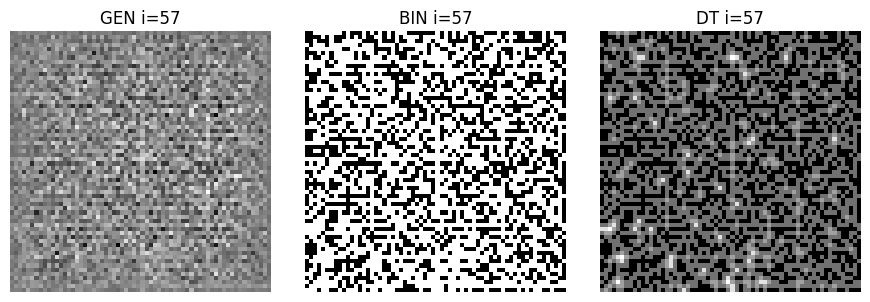

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 14.6509 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 49
Empty PD detected at sample 49 | dim=1 | Skipping padding and saving debug image...


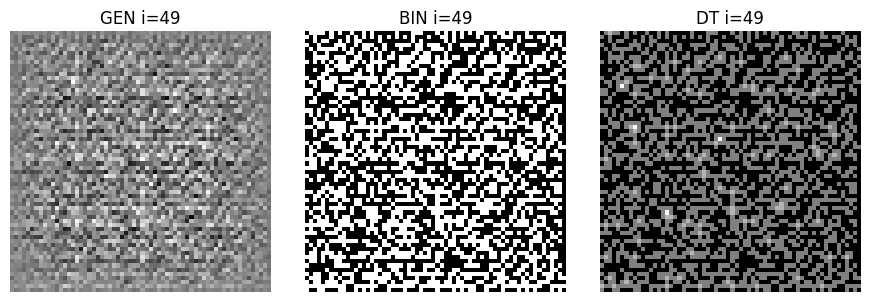

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[1/2000][0/1] D: 9.3934 G: 0.0313 T: 4.5366 W: 4.3061 Step: 1
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 136
Empty PD detected at sample 136 | dim=1 | Skipping padding and saving debug image...


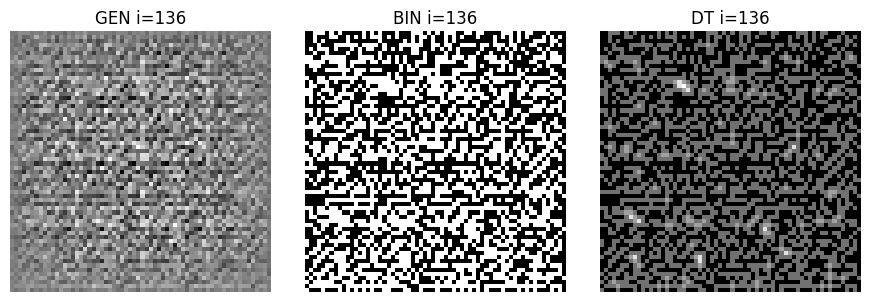

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.2484 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 134
Empty PD detected at sample 134 | dim=1 | Skipping padding and saving debug image...


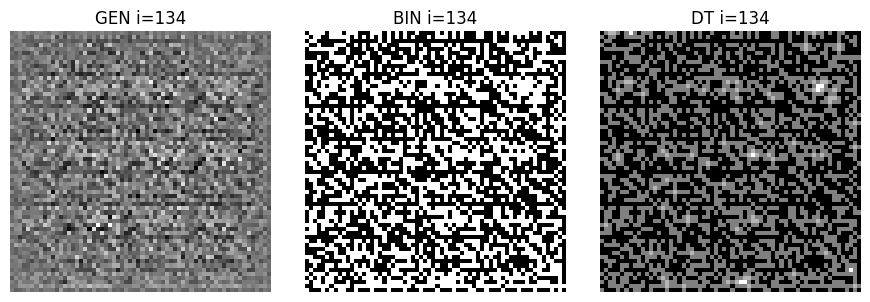

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.6880 seconds
[11/2000][0/1] D: 0.3905 G: 3.5614 T: 4.2467 W: 3.9264 Step: 11
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 80
Empty PD detected at sample 80 | dim=1 | Skipping padding and saving debug image...


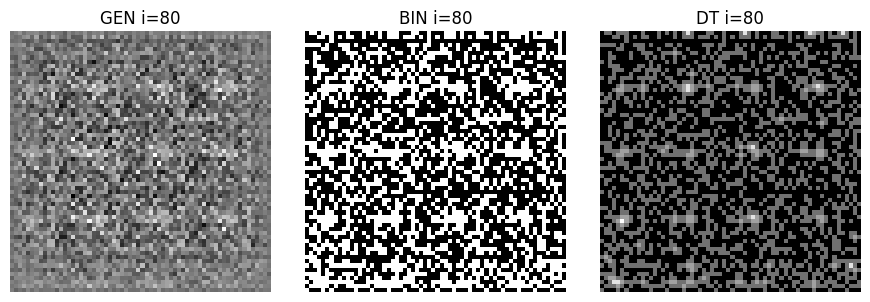

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 9.7427 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 35
Empty PD detected at sample 35 | dim=1 | Skipping padding and saving debug image...


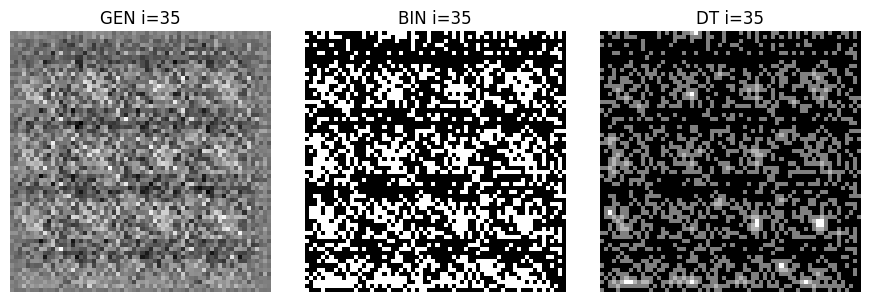

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.9672 seconds
[21/2000][0/1] D: -13.2523 G: 10.7675 T: 4.1653 W: 4.6037 Step: 21
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 30
Empty PD detected at sample 30 | dim=1 | Skipping padding and saving debug image...


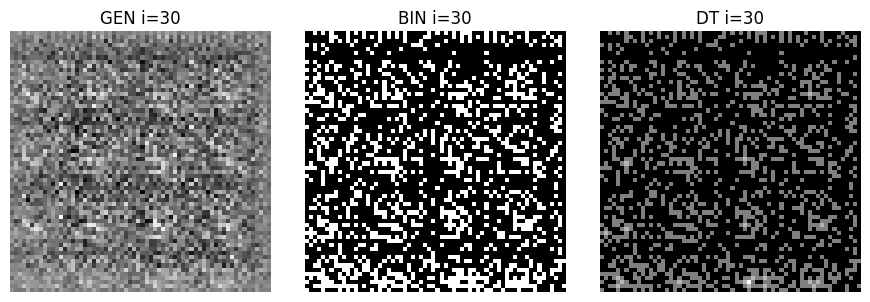

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 14.2088 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 98
Empty PD detected at sample 98 | dim=1 | Skipping padding and saving debug image...


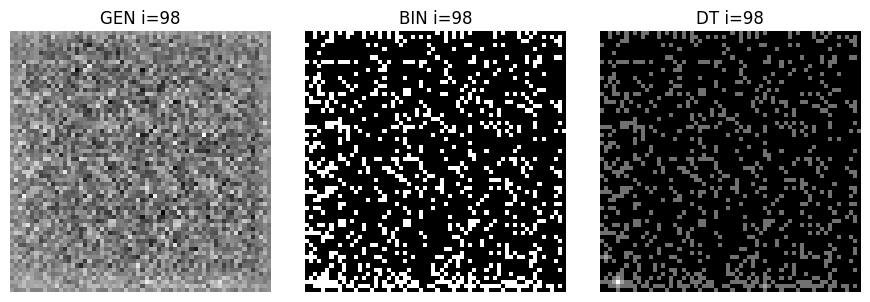

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 16.0655 seconds
[31/2000][0/1] D: -14.5364 G: 9.6361 T: 4.0575 W: 5.4825 Step: 31
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 216
Empty PD detected at sample 216 | dim=1 | Skipping padding and saving debug image...


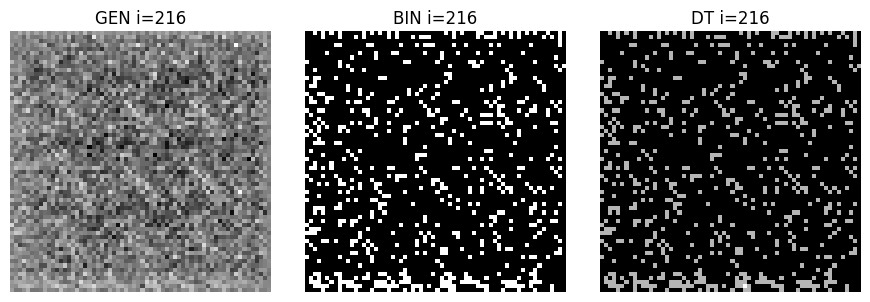

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 15.6351 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 289
Empty PD detected at sample 289 | dim=1 | Skipping padding and saving debug image...


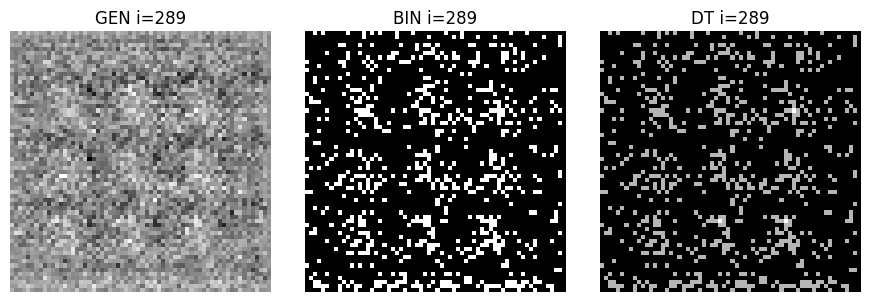

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 15.2427 seconds
[41/2000][0/1] D: -13.4234 G: 7.4831 T: 4.0785 W: 4.8905 Step: 41
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 68
Empty PD detected at sample 68 | dim=1 | Skipping padding and saving debug image...


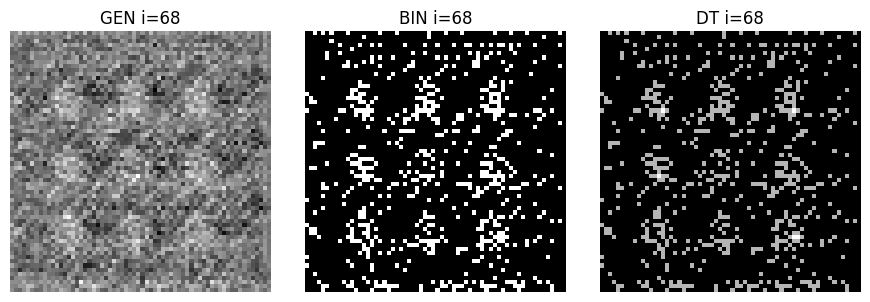

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 13.0186 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 38
Empty PD detected at sample 38 | dim=1 | Skipping padding and saving debug image...


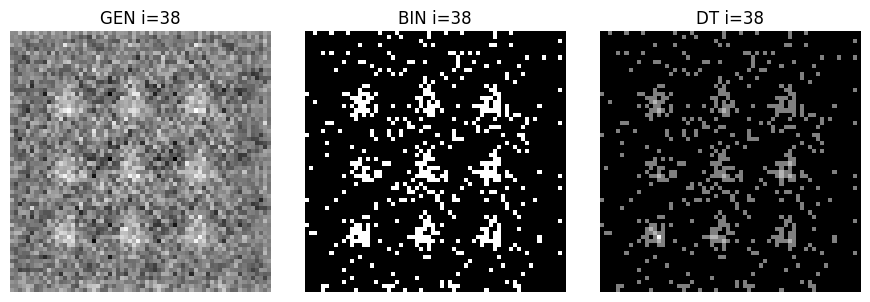

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.5395 seconds
Saving image and models...
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 55
Empty PD detected at sample 55 | dim=1 | Skipping padding and saving debug image...


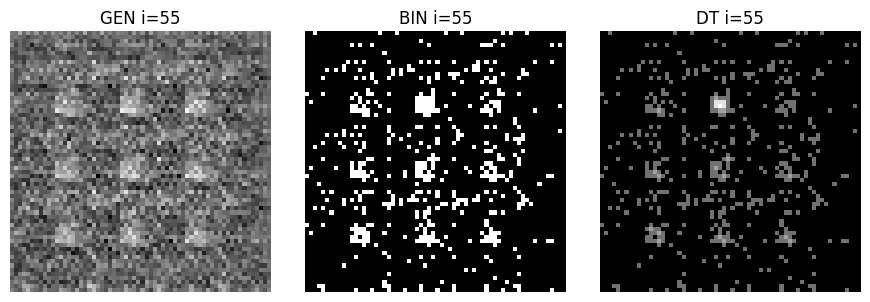

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[51/2000][0/1] D: -12.9011 G: 3.4999 T: 4.1706 W: 5.3712 Step: 51
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 261
Empty PD detected at sample 261 | dim=1 | Skipping padding and saving debug image...


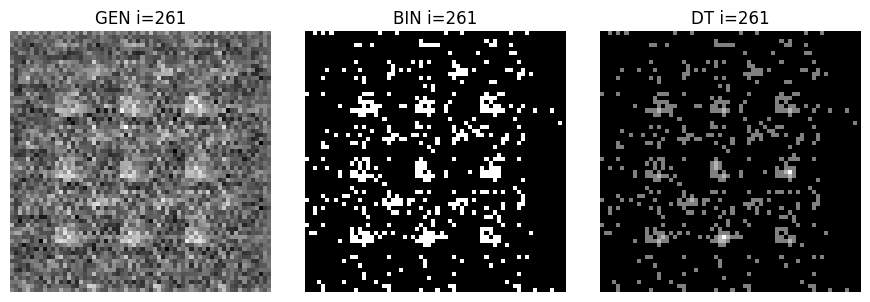

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 12.0605 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 291
Empty PD detected at sample 291 | dim=1 | Skipping padding and saving debug image...


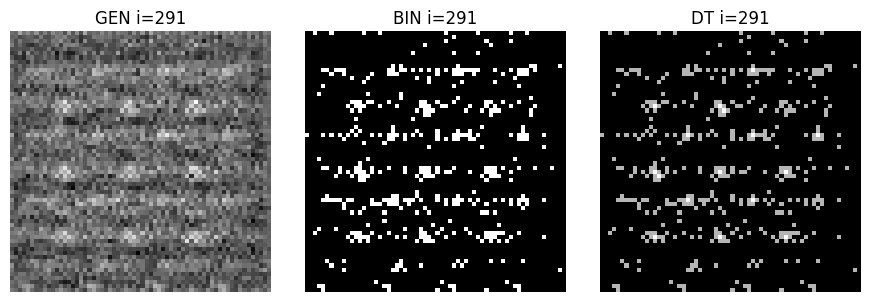

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 10.7284 seconds
[61/2000][0/1] D: -12.8143 G: 4.2088 T: 4.1566 W: 5.2439 Step: 61
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 243
Empty PD detected at sample 243 | dim=1 | Skipping padding and saving debug image...


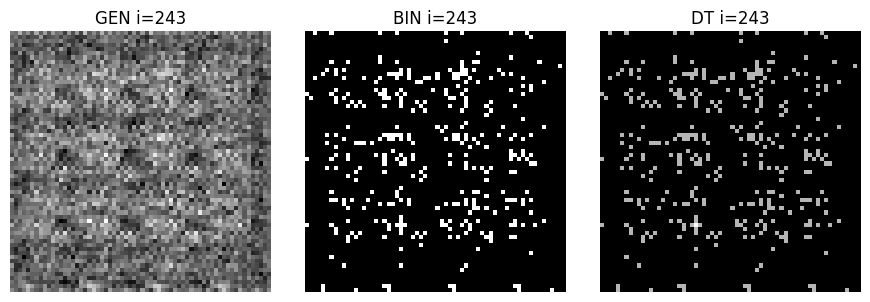

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 11.3502 seconds
gen shape (324, 1, 64, 64)
dim=/=0
Sanity Check Plot random example for i = 280
Empty PD detected at sample 280 | dim=1 | Skipping padding and saving debug image...


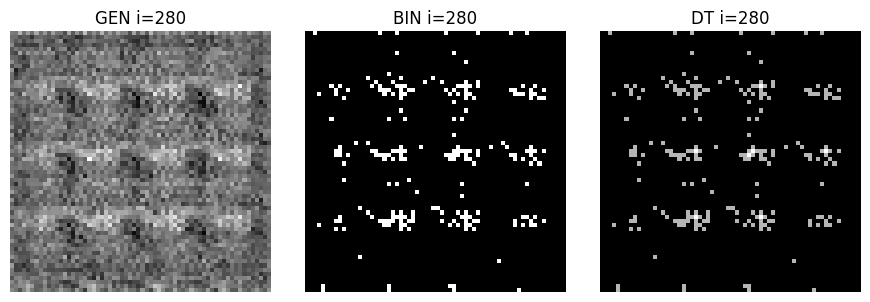

Computing 1D 1-wasserstein distance.
[<class 'list'>, <class 'numpy.ndarray'>, <class 'list'>, <class 'numpy.ndarray'>]
Lengths of set1 & set2:  324 32
[TIMER] G_iteration took 8.5019 seconds
[71/2000][0/1] D: -12.2438 G: 3.0504 T: 4.1648 W: 5.5910 Step: 71
gen shape (324, 1, 64, 64)
dim=/=0


In [ ]:
train()

# Plotting

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_persistence_diagram(
    mat, title="Persistence Diagram", show=True, save_path=None
):
    """
    Plot a persistence diagram given a matrix of birth-death pairs.

    Parameters:
        mat (np.ndarray): Array of shape (N, 2), where each row is (birth, death)
        title (str): Plot title
        show (bool): Whether to display the plot
        save_path (str or None): If given, saves the plot to this path
    """
    if mat.ndim != 2 or mat.shape[1] != 2:
        raise ValueError(
            "mat must be a 2D array with shape (N, 2), representing (birth, death) pairs."
        )

    births, deaths = mat[:, 0], mat[:, 1]

    plt.figure(figsize=(6, 6))
    plt.scatter(births, deaths, c="blue", alpha=0.6, edgecolors="k")
    max_val = max(np.max(births), np.max(deaths)) * 1.05
    plt.plot([0, max_val], [0, max_val], "r--", label="Diagonal (birth=death)")
    plt.xlabel("Birth")
    plt.ylabel("Death")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.axis("equal")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()


def plot_persistence_diagram_from_file(
    file_path, title="Persistence Diagram", show=True, save_path=None
):
    def read_matrix_binary(path, dtype="d"):
        file_in = open(path, "rb")
        dims = struct.unpack("I", file_in.read(4))[0]
        if dims == 0:
            return None
        shape = struct.unpack(str(dims) + "I", file_in.read(4 * dims))
        mat = struct.unpack(
            str(np.prod(shape)) + dtype,
            file_in.read(dlength_dict[dtype] * np.prod(shape)),
        )
        mat = np.reshape(mat, shape)
        return mat

    pd_matrix = read_matrix_binary(file_path)
    return plot_persistence_diagram(pd_matrix, title, show, save_path)

In [ ]:
from pathlib import Path

pds_path = Path("C:\TopoGAN-ECCV2020\Data\cremi\pds_64x64_downscaled_from_256")
pd_names = [
    "crop_00000.png.dat",
    "crop_00001.png.dat",
    "crop_00002.png.dat",
    "crop_00003.png.dat",
]

for name in pd_names:
    path = pds_path / name
    plot_persistence_diagram_from_file(path, title="PD_" + name)

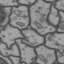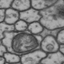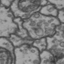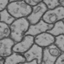

In [ ]:
%cd C:\TopoGAN-ECCV2020

In [ ]:
%run inference.ipynb

In [ ]:
from datetime import datetime
from pathlib import Path

experiment_name = "release_test_20250517_214006_64x64"
training_dataset_path = Path(r"C:\TopoGAN-ECCV2020\Data\cremi\64x64")
weights_path = Path(f"C:/TopoGAN-ECCV2020/Data/LOG/{experiment_name}/models")
generations_path = Path(f"C:/TopoGAN-ECCV2020/Data/generations/cremi/{experiment_name}")
step = 2000

# Get current datetime and format it as a string
current_time = datetime.now().strftime("%Y.%m.%d_%H.%M.%S")

# Add datetime to the end of the generations_path stem
new_name = f"{generations_path.stem}_{current_time}{generations_path.suffix}"
generations_path = generations_path.with_name(new_name)

gan_kwargs = {
    "general": general,
    "adv_params": adv_params,
    "G_arch": G_arch,
    "D_arch": D_arch,
}

generate_images(
    GAN,
    weights_path,
    generations_path,
    gan_kwargs=gan_kwargs,
    step=step,
    num_samples=1000,
    fix_with_topo=False,
)

os.chdir(HOME_DIR)
fid = compute_fid([str(generations_path), str(training_dataset_path)])
print("fid")
save_to_log(fid, experiment_name)

In [ ]:
os.chdir(HOME_DIR)

In [ ]:
compute_fid([str(generations_path), str(training_dataset_path)])

In [ ]:
compute_fid([str(generations_path), str(generations_path)])

# Experiment runner

In [ ]:
import os
import sys

import numpy

# Add OpenBLAS bin to the beginning of the PATH
os.environ["PATH"] = r"C:\TopoGAN-ECCV2020\OpenBLAS\bin;" + os.environ.get("PATH", "")

# # 1) register the folder that contains _persis_homo_optimal.pyd *and* any other DLLs it needs
# os.add_dll_directory(r"C:\Users\MIKEC\PycharmProjects\topology\TopoGAN-ECCV2020\persis_lib_cpp")

# 2) add the same folder to sys.path so Python can find the .pyd module by name
# sys.path.insert(0, r"C:\Users\MIKEC\PycharmProjects\topology\TopoGAN-ECCV2020\persis_lib_cpp")

# python library compile from cpp
sys.path.insert(0, "./persis_lib_cpp")
import os

from persis_homo_optimal import *

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Добавьте это в первой ячейке
TOPOLOGICAL_GAN = True
START_TOPO_LOSS_FROM_EPOCH = -1

%run Archpool.ipynb
%run Argparser.ipynb
%run GAN.ipynb


def precompute_pds(dir_in, dir_out):
    adv_params = return_advanced_params()
    et = Edges_(adv_params, False)
    FileIO.compute_pd_save(dir_in, dir_out, "png", adv_params, 1, True)


%run experiment_engine.ipynb
%run inference.ipynb

%run Archpool.ipynb
%run Argparser.ipynb
%run GAN.ipynb
%run fid/inception.ipynb
%run fid/fid_score.ipynb

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

HOME_DIR = "C:\TopoGAN-ECCV2020"

In [ ]:
from pathlib import Path

experiment_names = [
    "release_test_20250514_165411_64x64_downscaled_from_128_n350",
    # Add more here
]

# Define only the root (everything else will be extracted from JSON)
base_path = Path(r"C:/TopoGAN-ECCV2020/Data")

# run_experiments_from_logs(
#     experiment_names=experiment_names,
#     GAN=GAN,
#     generate_images=generate_images,
#     compute_fid=compute_fid,
#     HOME_DIR=HOME_DIR,
#     base_log_path=base_path / "LOG",
#     base_generation_path_root=base_path / "generations",
#     num_samples=100,
#     fix_with_topo=False,
# )

run_experiments_from_logs(
    experiment_names=experiment_names,
    GAN=GAN,
    generate_images=generate_images,
    compute_fid=compute_fid,
    HOME_DIR=HOME_DIR,
    base_log_path=base_path / "LOG",
    base_generation_path_root=base_path / "generations",
    base_data_path=base_path,
    step=1950,
    num_samples=100,
    fix_with_topo=False,
)